# Malaria Risk Classification: Train/Validation/Test Evaluation

This notebook contains the supervised AI/ML workflow that was separated from the geospatial assignment notebook.

Objective: predict whether a state will be high malaria risk in the next year using only information available up to the current feature year.

The workflow avoids two common evaluation problems:

- the high-risk threshold is estimated from the training period only
- model selection is done on a validation period, not on the final test period

## 0. Setup

Run the install cell once only if packages are missing from the selected kernel.

In [1]:
# Uncomment and run this cell if packages are missing.
# %pip install pandas numpy matplotlib scikit-learn

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_READY_DIR = DATA_DIR / "analysis_ready"
STATE_YEAR_CSV = ANALYSIS_READY_DIR / "state_year_malaria_clean.csv"
AIML_FEATURES_CSV = ANALYSIS_READY_DIR / "aiml_state_year_features.csv"

SELECTED_REGIONS = ["Odisha", "Mizoram", "Tripura"]
TRAIN_END_YEAR = 2016
VALIDATION_END_YEAR = 2019
TEST_START_YEAR = 2020
RISK_QUANTILE = 0.75
RANDOM_STATE = 42

## 1. Load Prepared Data

`state_year_malaria_clean.csv` is used for trend inspection. `aiml_state_year_features.csv` contains the lagged model features and next-year outcome columns.

In [3]:
state_year = pd.read_csv(STATE_YEAR_CSV)
model_df = pd.read_csv(AIML_FEATURES_CSV)

numeric_state_cols = [
    "year",
    "total_cases",
    "total_deaths",
    "district_count",
    "population_2011",
    "cases_per_100k",
    "deaths_per_100k",
]
for col in numeric_state_cols:
    state_year[col] = pd.to_numeric(state_year[col], errors="coerce")

numeric_model_cols = [col for col in model_df.columns if col not in {"state", "selected_region"}]
for col in numeric_model_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("State-year rows:", len(state_year))
print("ML feature rows before filtering:", len(model_df))
print("States/UTs:", state_year["state"].nunique())
print("State-year range:", int(state_year["year"].min()), "-", int(state_year["year"].max()))
display(model_df.head())

State-year rows: 858
ML feature rows before filtering: 706
States/UTs: 38
State-year range: 2000 - 2024


,state,year,population_2011,district_count,total_cases,cases_per_100k,total_cases_lag1,total_cases_lag2,total_cases_lag3,total_deaths_lag1,...,cases_per_100k_lag2,cases_per_100k_lag3,deaths_per_100k_lag1,cases_rate_roll3,cases_yoy_change,rate_yoy_change,next_year_cases,next_year_rate,high_risk_next_year,selected_region
0,Andaman And Nicobar Islands,2003,380581,1,427,112.196878,1557,434,1990,4,...,114.036171,522.884747,1.051025,348.677417,-0.725755,-0.725755,1800,472.961078,1,no
1,Andaman And Nicobar Islands,2004,380581,4,1800,472.961078,427,1557,434,0,...,409.111332,114.036171,0.000000,211.781460,3.215457,3.215457,3234,849.753403,1,no
2,Andaman And Nicobar Islands,2005,380581,1,3234,849.753403,1800,427,1557,4,...,112.196878,409.111332,1.051025,331.423096,0.796667,0.796667,18866,4957.157609,1,no
3,Andaman And Nicobar Islands,2006,380581,7,18866,4957.157609,3234,1800,427,0,...,472.961078,112.196878,0.000000,478.303786,4.833643,4.833643,29938,7866.393751,1,no
4,Andaman And Nicobar Islands,2008,380581,8,29938,7866.393751,18866,3234,1800,22,...,849.753403,472.961078,5.780635,2093.290697,0.586876,0.586876,22081,5801.918645,1,no


## 2. Quick Exploratory Check

The selected regions are kept for interpretation, but the classifier is trained across all available states/UTs to provide enough examples.

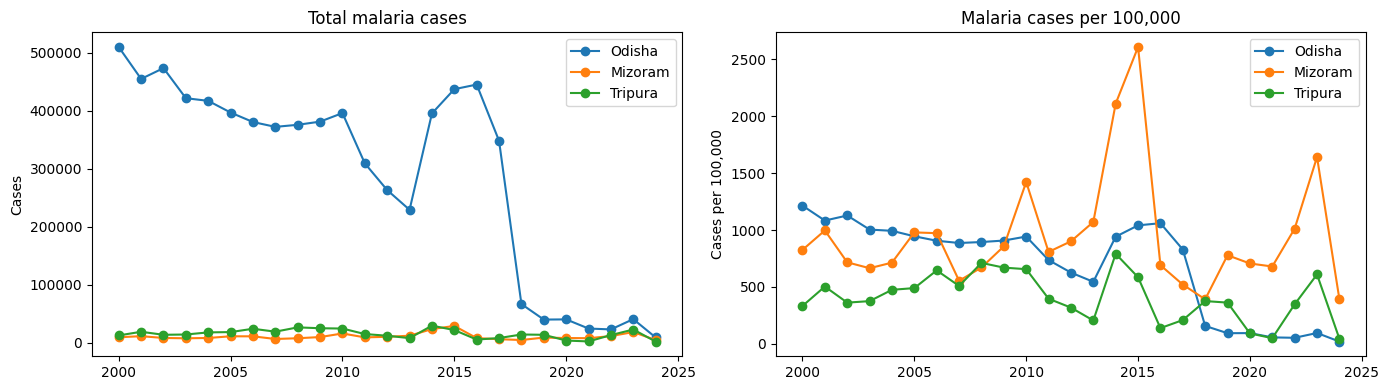

In [4]:
selected = state_year[state_year["state"].isin(SELECTED_REGIONS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for region in SELECTED_REGIONS:
    region_df = selected[selected["state"] == region].sort_values("year")
    axes[0].plot(region_df["year"], region_df["total_cases"], marker="o", label=region)
    axes[1].plot(region_df["year"], region_df["cases_per_100k"], marker="o", label=region)

axes[0].set_title("Total malaria cases")
axes[0].set_ylabel("Cases")
axes[0].legend()
axes[1].set_title("Malaria cases per 100,000")
axes[1].set_ylabel("Cases per 100,000")
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Define Features and Target Without Leakage

The source feature table includes a precomputed `high_risk_next_year` column. This notebook ignores that saved label and recomputes the label using a threshold learned only from the training period.

The target is:

`high_risk_next_year = 1` if the next year's cases per 100,000 are at or above the 75th percentile of training-period next-year rates.

In [5]:
feature_cols = [
    "year",
    "population_2011",
    "district_count",
    "total_cases_lag1",
    "total_cases_lag2",
    "total_cases_lag3",
    "total_deaths_lag1",
    "cases_per_100k_lag1",
    "cases_per_100k_lag2",
    "cases_per_100k_lag3",
    "deaths_per_100k_lag1",
    "cases_rate_roll3",
    "cases_yoy_change",
    "rate_yoy_change",
]

essential_cols = feature_cols + ["state", "cases_per_100k", "next_year_rate"]
model_df = model_df.dropna(subset=essential_cols).copy()

training_label_source = model_df[model_df["year"] <= TRAIN_END_YEAR]
risk_threshold = training_label_source["next_year_rate"].quantile(RISK_QUANTILE)
model_df["high_risk_next_year"] = (model_df["next_year_rate"] >= risk_threshold).astype(int)
model_df["prediction_year"] = model_df["year"] + 1

print("Training-only high-risk threshold:", round(risk_threshold, 2), "cases per 100,000")
print("Rows after feature filtering:", len(model_df))
print("Overall high-risk rate:", round(model_df["high_risk_next_year"].mean(), 3))
display(model_df[["state", "year", "prediction_year", "cases_per_100k", "next_year_rate", "high_risk_next_year"]].head())

Training-only high-risk threshold: 356.85 cases per 100,000
Rows after feature filtering: 700
Overall high-risk rate: 0.187


,state,year,prediction_year,cases_per_100k,next_year_rate,high_risk_next_year
0,Andaman And Nicobar Islands,2003,2004,112.196878,472.961078,1
1,Andaman And Nicobar Islands,2004,2005,472.961078,849.753403,1
2,Andaman And Nicobar Islands,2005,2006,849.753403,4957.157609,1
3,Andaman And Nicobar Islands,2006,2007,4957.157609,7866.393751,1
4,Andaman And Nicobar Islands,2008,2009,7866.393751,5801.918645,1


## 4. Train / Validation / Test Split

The split is chronological:

- training: feature years through 2016
- validation: feature years 2017-2019
- test: feature years 2020 onward

The validation period is used to choose the model. The test period is used only once for final reporting.

In [6]:
train = model_df[model_df["year"] <= TRAIN_END_YEAR].copy()
validation = model_df[(model_df["year"] > TRAIN_END_YEAR) & (model_df["year"] <= VALIDATION_END_YEAR)].copy()
test = model_df[model_df["year"] >= TEST_START_YEAR].copy()

X_train = train[feature_cols]
y_train = train["high_risk_next_year"]
X_validation = validation[feature_cols]
y_validation = validation["high_risk_next_year"]
X_test = test[feature_cols]
y_test = test["high_risk_next_year"]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "first_year": train["year"].min(), "last_year": train["year"].max(), "high_risk_rate": y_train.mean()},
    {"split": "validation", "rows": len(validation), "first_year": validation["year"].min(), "last_year": validation["year"].max(), "high_risk_rate": y_validation.mean()},
    {"split": "test", "rows": len(test), "first_year": test["year"].min(), "last_year": test["year"].max(), "high_risk_rate": y_test.mean()},
])
display(split_summary)

,split,rows,first_year,last_year,high_risk_rate
0,train,472,2003,2016,0.250000
1,validation,102,2017,2019,0.058824
2,test,126,2020,2023,0.055556


## 5. Train Candidate Models and Select on Validation

The dummy baseline is included so the ML models must beat a simple majority-class strategy. Selection uses validation F1 first and average precision second.

In [7]:
def evaluate_classifier(model, X, y, split_name):
    pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X)[:, 1]
    else:
        prob = pred.astype(float)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y, pred, average="binary", zero_division=0
    )

    return {
        "split": split_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "roc_auc": roc_auc_score(y, prob) if len(set(y)) > 1 else np.nan,
        "average_precision": average_precision_score(y, prob) if len(set(y)) > 1 else np.nan,
    }

models = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=3,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

validation_results = []
fitted_on_train = {}

for name, model in models.items():
    fitted = clone(model)
    fitted.fit(X_train, y_train)
    fitted_on_train[name] = fitted
    row = evaluate_classifier(fitted, X_validation, y_validation, "validation")
    row["model"] = name
    validation_results.append(row)

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(["f1", "average_precision", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df[["model", "precision", "recall", "f1", "balanced_accuracy", "roc_auc", "average_precision"]])

best_model_name = validation_results_df.loc[0, "model"]
print("Selected model from validation period:", best_model_name)

,model,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,Random Forest,0.357143,0.833333,0.500000,0.869792,0.930556,0.325382
1,Gradient Boosting,0.333333,0.500000,0.400000,0.718750,0.923611,0.303482
2,Logistic Regression,0.250000,0.500000,0.333333,0.703125,0.913194,0.294853
3,Dummy baseline,0.000000,0.000000,0.000000,0.500000,0.500000,0.058824


Selected model from validation period: Random Forest


## 6. Final Test Evaluation

After selecting the model on validation data, refit that model on training plus validation data, then evaluate once on the held-out test period.

,model,split,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,Random Forest,test,1.0,0.857143,0.923077,0.928571,0.996399,0.957143


               precision    recall  f1-score   support

not high risk       0.99      1.00      1.00       119
    high risk       1.00      0.86      0.92         7

     accuracy                           0.99       126
    macro avg       1.00      0.93      0.96       126
 weighted avg       0.99      0.99      0.99       126



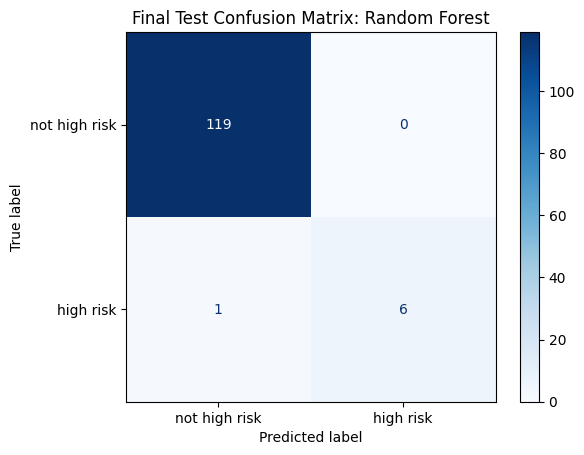

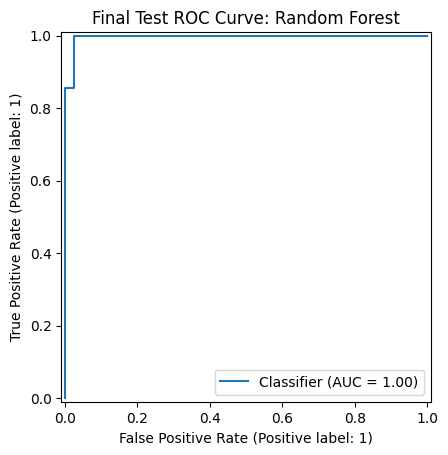

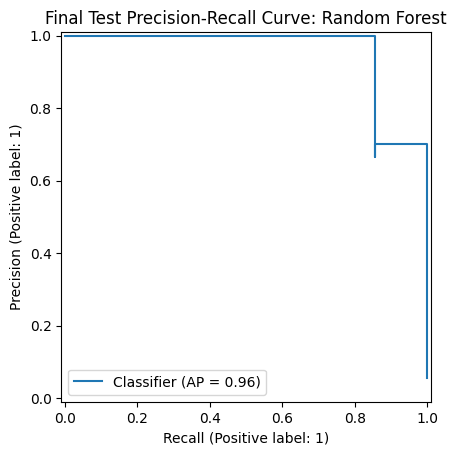

In [8]:
train_validation = pd.concat([train, validation], ignore_index=True)
X_train_validation = train_validation[feature_cols]
y_train_validation = train_validation["high_risk_next_year"]

final_model = clone(models[best_model_name])
final_model.fit(X_train_validation, y_train_validation)

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else final_pred.astype(float)

final_metrics = evaluate_classifier(final_model, X_test, y_test, "test")
final_metrics["model"] = best_model_name
display(pd.DataFrame([final_metrics])[["model", "split", "precision", "recall", "f1", "balanced_accuracy", "roc_auc", "average_precision"]])

print(classification_report(y_test, final_pred, target_names=["not high risk", "high risk"], zero_division=0))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, final_pred),
    display_labels=["not high risk", "high risk"],
).plot(cmap="Blues")
plt.title(f"Final Test Confusion Matrix: {best_model_name}")
plt.show()

if len(set(y_test)) > 1:
    RocCurveDisplay.from_predictions(y_test, final_prob)
    plt.title(f"Final Test ROC Curve: {best_model_name}")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, final_prob)
    plt.title(f"Final Test Precision-Recall Curve: {best_model_name}")
    plt.show()

## 7. Feature Importance

Feature importance is interpreted according to the selected model type. Tree models use model-provided importances; logistic regression uses absolute coefficient size after scaling.

,feature,importance
0,cases_per_100k_lag1,0.213563
1,cases_rate_roll3,0.199963
2,cases_per_100k_lag3,0.178255
3,cases_per_100k_lag2,0.137683
4,deaths_per_100k_lag1,0.062418
5,population_2011,0.039819
6,cases_yoy_change,0.027622
7,rate_yoy_change,0.026658
8,total_cases_lag1,0.021487
9,total_cases_lag3,0.019967


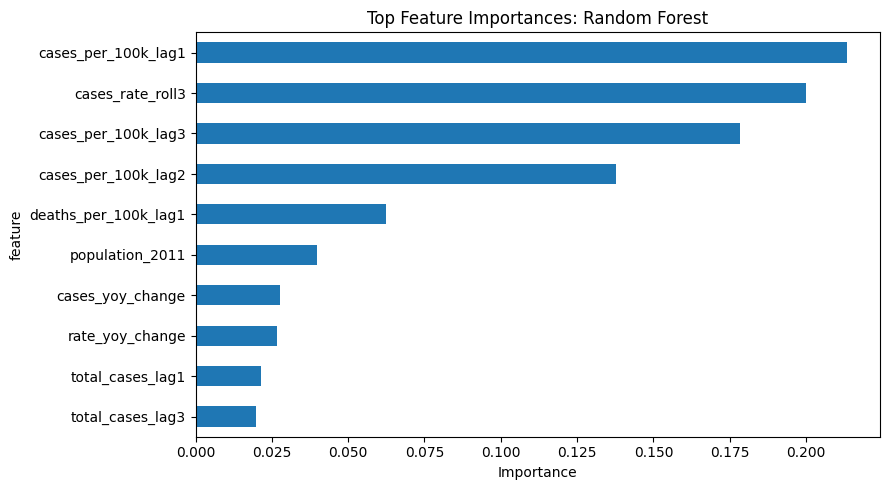

In [9]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importance_values = final_model.feature_importances_
elif best_model_name == "Logistic Regression":
    importance_values = np.abs(final_model.named_steps["model"].coef_[0])
else:
    importance_values = np.zeros(len(feature_cols))

importance_df = (
    pd.DataFrame({"feature": feature_cols, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

importance_df.head(10).sort_values("importance").plot(
    x="feature", y="importance", kind="barh", figsize=(9, 5), legend=False
)
plt.title(f"Top Feature Importances: {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Predictions for Selected Regions

`year` is the feature year. `prediction_year` is the year being predicted.

In [10]:
prediction_table = test.copy()
prediction_table["predicted_high_risk"] = final_pred
prediction_table["predicted_high_risk_probability"] = final_prob

selected_predictions = prediction_table[prediction_table["state"].isin(SELECTED_REGIONS)][
    [
        "state",
        "year",
        "prediction_year",
        "cases_per_100k",
        "next_year_rate",
        "high_risk_next_year",
        "predicted_high_risk",
        "predicted_high_risk_probability",
    ]
].sort_values(["state", "year"])

display(selected_predictions)

,state,year,prediction_year,cases_per_100k,next_year_rate,high_risk_next_year,predicted_high_risk,predicted_high_risk_probability
462,Mizoram,2020,2021,706.157276,679.635365,1,1,0.709399
463,Mizoram,2021,2022,679.635365,1011.660527,1,1,0.771674
464,Mizoram,2022,2023,1011.660527,1640.530584,1,1,0.835761
465,Mizoram,2023,2024,1640.530584,392.633653,1,1,0.838277
504,Odisha,2020,2021,95.020234,57.435257,0,0,0.359701
505,Odisha,2021,2022,57.435257,53.818751,0,0,0.001612
506,Odisha,2022,2023,53.818751,96.011318,0,0,0.002500
507,Odisha,2023,2024,96.011318,20.827071,0,0,0.037230
630,Tripura,2020,2021,92.408185,50.681602,0,0,0.185291
631,Tripura,2021,2022,50.681602,347.612643,0,0,0.107338


## 9. Interpretation Checklist

Use the outputs above to discuss:

1. Whether the chosen model beats the dummy baseline on validation data.
2. Whether final test recall is acceptable for public-health risk screening.
3. Which lagged burden features matter most.
4. Whether Odisha, Mizoram, and Tripura remain high-risk in the held-out test period.
5. Limitations: the model does not include rainfall, temperature, vector abundance, intervention coverage, or surveillance changes.